In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, roc_curve,
                             precision_recall_curve, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
import pickle
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
print(" All libraries imported!")

 All libraries imported!


In [34]:
import os 
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath("__file__")))

# Load Data from PostgreSQL

In [ ]:
from dotenv import load_dotenv
import os
load_dotenv()
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

# Load raw data with all features
df = pd.read_sql("SELECT * FROM telco_raw", engine)

# Load segment labels we created in Phase 2
segments = pd.read_sql('SELECT "CustomerID", "Segment", "RFM_Score" FROM customer_segments', engine)

# Merge segment info into main dataframe
df = df.merge(segments, on="CustomerID", how="left")

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (7043, 35)
Columns: ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason', 'Segment', 'RFM_Score']


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Segment,RFM_Score
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,High Risk,6
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,High Risk,5
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Electronic check,99.65,820.5,Yes,1,86,5372,Moved,High Risk,11
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved,Champions,13
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices,Champions,14


#  Data Preprocessing

In [36]:
# Drop columns that are not useful for prediction
drop_cols = [
    "CustomerID", "Count", "Country", "State", "City",
    "Zip Code", "Lat Long", "Latitude", "Longitude",
    "Churn Label",    # text version of target — we use Churn Value
    "Churn Score",    # this is a pre-computed score, leaks the target
    "Churn Reason",   # only available after churn happens, not before
    "CLTV"            # keep for analysis but remove for fair prediction
]

df_model = df.drop(columns=drop_cols)

# Fix TotalCharges — stored as string
df_model["Total Charges"] = pd.to_numeric(df_model["Total Charges"], errors="coerce")
df_model["Total Charges"].fillna(0, inplace=True)

# Fix SeniorCitizen
df_model["Senior Citizen"] = df_model["Senior Citizen"].map({0:"No", 1:"Yes"})

print(f"Shape after dropping: {df_model.shape}")
print(f"\nTarget distribution:")
print(df_model["Churn Value"].value_counts())

Shape after dropping: (7043, 22)

Target distribution:
Churn Value
0    5174
1    1869
Name: count, dtype: int64


# Encode Categorical Columns

In [37]:
# Separate target
X = df_model.drop(columns=["Churn Value"])
y = df_model["Churn Value"]

# Find categorical columns
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
print(f"Categorical columns to encode: {cat_cols}")

# Label encode all categorical columns
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

print(f"\nShape of X: {X.shape}")
print(f"Shape of y: {y.shape}")
print(f"Churn rate: {y.mean()*100:.1f}%")

Categorical columns to encode: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Segment']

Shape of X: (7043, 21)
Shape of y: (7043,)
Churn rate: 26.5%


# Train Test Split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42,
    stratify=y          # keeps same churn ratio in both splits
)

print(f"Training set  : {X_train.shape}")
print(f"Test set      : {X_test.shape}")
print(f"Train churn % : {y_train.mean()*100:.1f}%")
print(f"Test churn %  : {y_test.mean()*100:.1f}%")

Training set  : (5634, 21)
Test set      : (1409, 21)
Train churn % : 26.5%
Test churn %  : 26.5%


#  Handle Class Imbalance with SMOTE

In [39]:
# Apply SMOTE only on training data — NEVER on test data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE : {pd.Series(y_train_sm).value_counts().to_dict()}")
print(f"\nTraining set size after SMOTE: {X_train_sm.shape}")

Before SMOTE: {0: 4139, 1: 1495}
After SMOTE : {0: 4139, 1: 4139}

Training set size after SMOTE: (8278, 21)


#  Baseline: Logistic Regression

In [40]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_sm, y_train_sm)

lr_pred  = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)[:, 1]
lr_auc   = roc_auc_score(y_test, lr_proba)

print(f"Logistic Regression AUC: {lr_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Logistic Regression AUC: 0.8704

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.80      0.85      1035
           1       0.57      0.75      0.65       374

    accuracy                           0.79      1409
   macro avg       0.74      0.78      0.75      1409
weighted avg       0.81      0.79      0.79      1409



# Baseline: Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)

rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_auc   = roc_auc_score(y_test, rf_proba)

print(f"Random Forest AUC: {rf_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

# Main Model: XGBoost

In [42]:
xgb_model = xgb.XGBClassifier(
    n_estimators    = 300,
    max_depth       = 5,
    learning_rate   = 0.05,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    use_label_encoder=False,
    eval_metric     = "auc",
    random_state    = 42,
    n_jobs          = -1
)

xgb_model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    verbose=50
)

xgb_pred  = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc   = roc_auc_score(y_test, xgb_proba)

print(f"\nXGBoost AUC: {xgb_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

[0]	validation_0-auc:0.80998
[50]	validation_0-auc:0.85734
[100]	validation_0-auc:0.86350
[150]	validation_0-auc:0.86593
[200]	validation_0-auc:0.86648
[250]	validation_0-auc:0.86835
[299]	validation_0-auc:0.86755

XGBoost AUC: 0.8675

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.86      0.87      1035
           1       0.63      0.67      0.65       374

    accuracy                           0.81      1409
   macro avg       0.76      0.76      0.76      1409
weighted avg       0.81      0.81      0.81      1409



# Model Comparison

              Model  AUC Score
Logistic Regression   0.870358
            XGBoost   0.867546
      Random Forest   0.849620


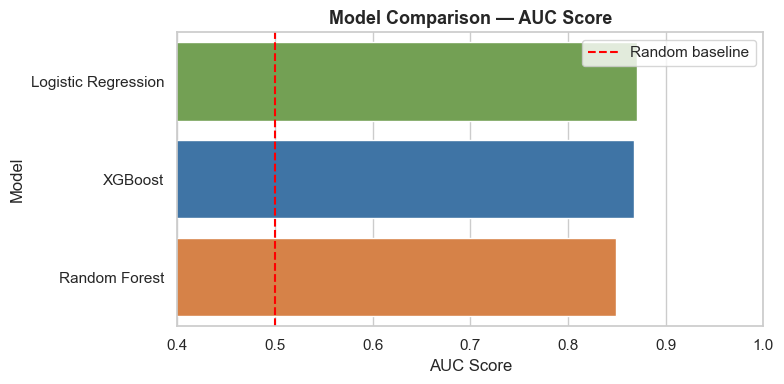

In [43]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "AUC Score": [lr_auc, rf_auc, xgb_auc]
}).sort_values("AUC Score", ascending=False)

print(results.to_string(index=False))

plt.figure(figsize=(8, 4))
bars = sns.barplot(x="AUC Score", y="Model", data=results,
                   palette=["#70AD47","#2E75B6","#ED7D31"])
plt.axvline(x=0.5, color="red", linestyle="--", label="Random baseline")
plt.xlim(0.4, 1.0)
plt.title("Model Comparison — AUC Score", fontsize=13, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/data/processed/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

#  ROC Curve

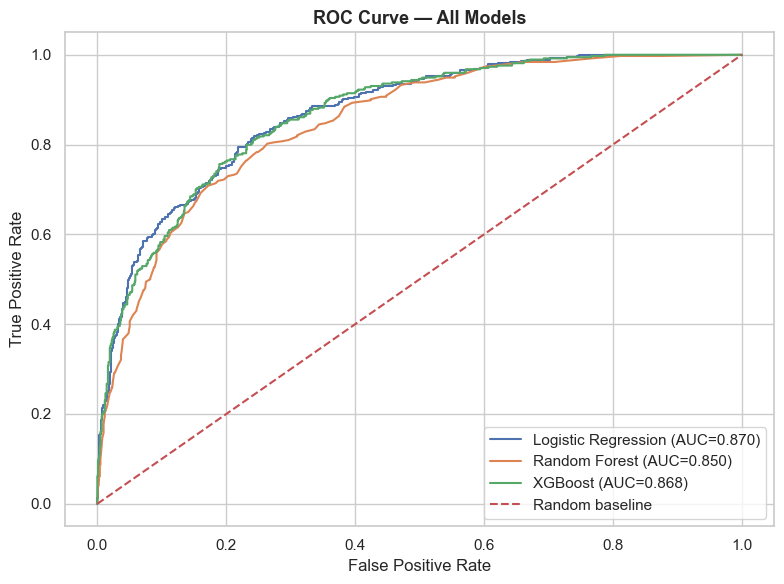

In [44]:
plt.figure(figsize=(8, 6))

for name, proba in [("Logistic Regression", lr_proba),
                     ("Random Forest", rf_proba),
                     ("XGBoost", xgb_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1], "r--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — All Models", fontsize=13, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/data/processed/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

# Confusion Matrix

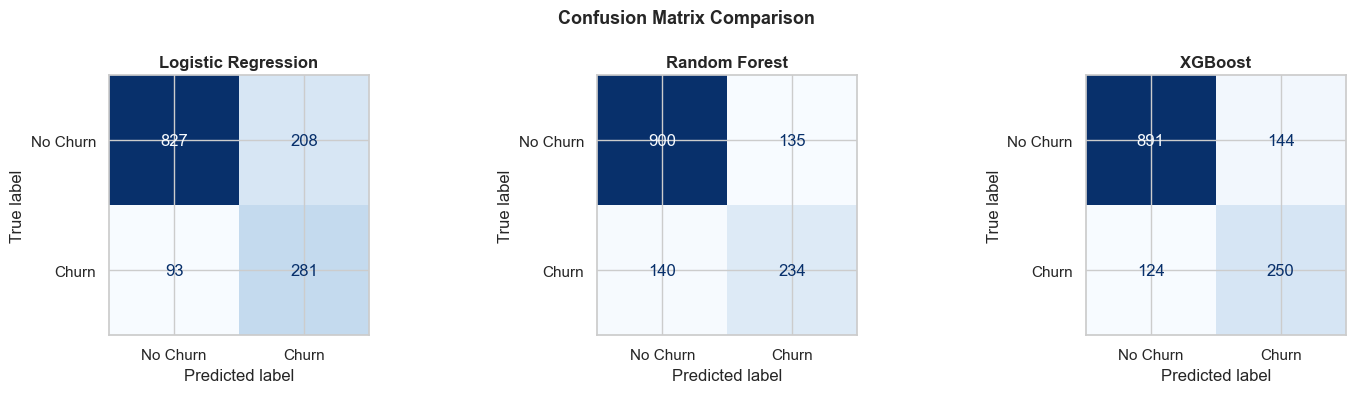

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, pred) in zip(axes, [
    ("Logistic Regression", lr_pred),
    ("Random Forest", rf_pred),
    ("XGBoost", xgb_pred)
]):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Churn","Churn"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontweight="bold")

plt.suptitle("Confusion Matrix Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/data/processed/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# SHAP Explainability

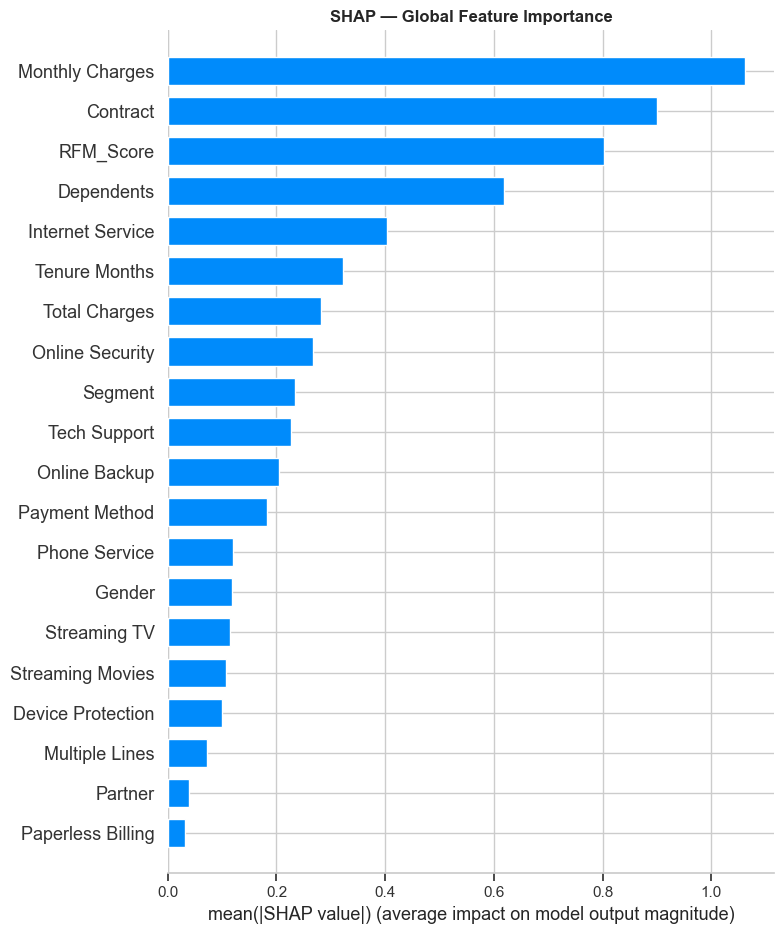

In [46]:
# SHAP explains WHY the model made each prediction
explainer  = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Global feature importance
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP — Global Feature Importance", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/data/processed/shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# SHAP Waterfall for 3 Customers


--- High Risk Customer ---
Churn Probability: 88.7%


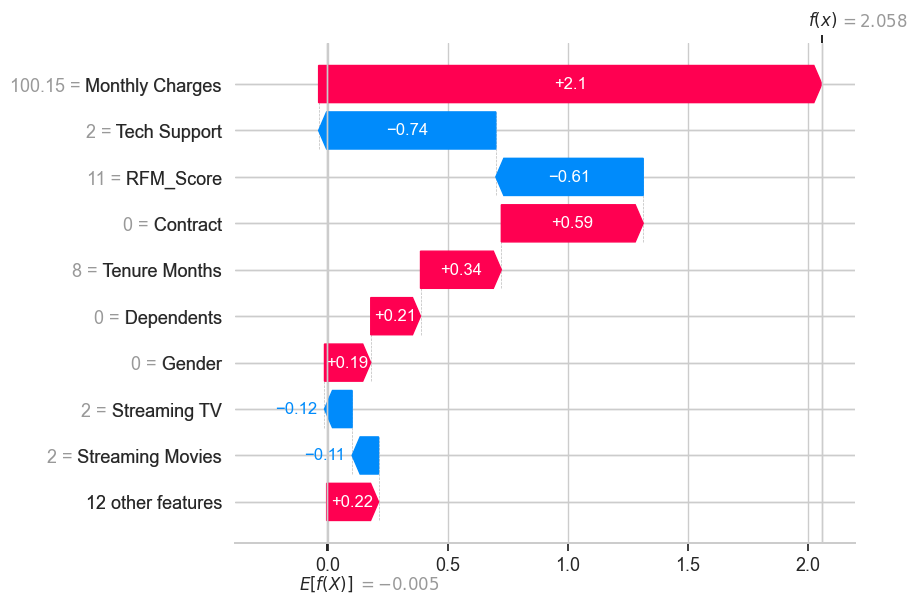


--- Low Risk Customer ---
Churn Probability: 2.3%


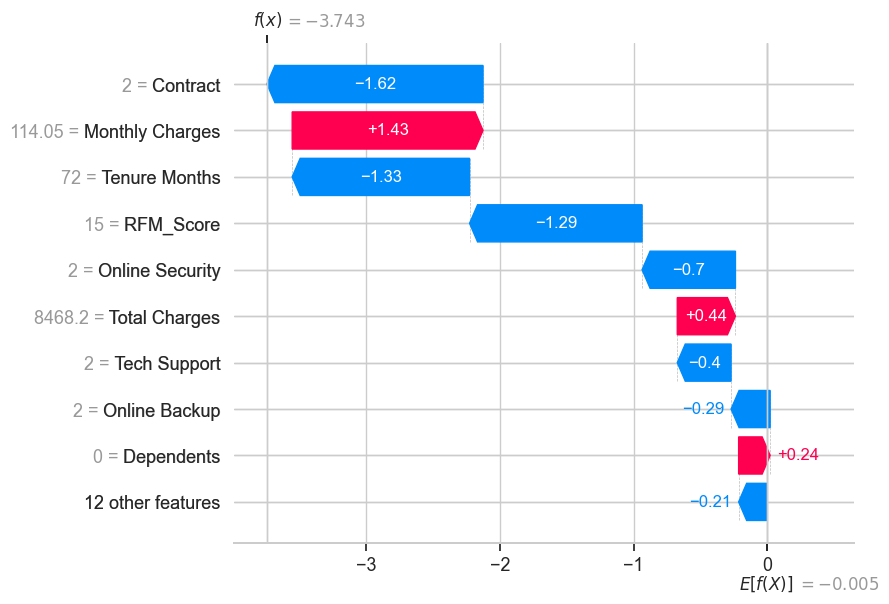

In [47]:
# Show why specific customers are predicted to churn
high_risk_idx  = X_test[xgb_proba > 0.8].index[:1]   # very likely to churn
low_risk_idx   = X_test[xgb_proba < 0.2].index[:1]   # very unlikely to churn

for label, idx in [("High Risk Customer", high_risk_idx),
                    ("Low Risk Customer",  low_risk_idx)]:
    if len(idx) > 0:
        i = X_test.index.get_loc(idx[0])
        print(f"\n--- {label} ---")
        print(f"Churn Probability: {xgb_proba[i]:.1%}")
        shap.waterfall_plot(
            shap.Explanation(
                values    = shap_values[i],
                base_values = explainer.expected_value,
                data      = X_test.iloc[i],
                feature_names = X_test.columns.tolist()
            )
        )

# Save Predictions & Model

In [48]:
# Add predictions to test set
results_df = X_test.copy()
results_df["Actual_Churn"]      = y_test.values
results_df["Churn_Probability"] = xgb_proba
results_df["Predicted_Churn"]   = xgb_pred
results_df["Risk_Level"] = pd.cut(
    results_df["Churn_Probability"],
    bins=[0, 0.3, 0.6, 1.0],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

# Save predictions to CSV
results_df.to_csv(f"{BASE_DIR}/data/predictions/churn_predictions.csv", index=False)
print(f"✅ Predictions saved: {results_df.shape}")
print(f"\nRisk Level Distribution:")
print(results_df["Risk_Level"].value_counts())

# Save model
with open(f"{BASE_DIR}/models/xgb_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)
print("\n✅ Model saved to models/xgb_model.pkl")

# Save feature names for Streamlit app
with open(f"{BASE_DIR}/models/feature_names.pkl", "wb") as f:
    pickle.dump(X_test.columns.tolist(), f)
print("✅ Feature names saved!")

✅ Predictions saved: (1409, 25)

Risk Level Distribution:
Risk_Level
Low Risk       840
High Risk      319
Medium Risk    250
Name: count, dtype: int64

✅ Model saved to models/xgb_model.pkl
✅ Feature names saved!
